# Officina 003: concrete-actions

This iteration runs the production generation, page drawing, synthetic handwriting, reading and continuation functions through one game. The household and replies are synthetic. Cloud calls incur usage. No physical printer, camera, deployed HTTP API, parent approval or household clock is exercised. Declared minutes are document timings, not measured human time.

Acceptance requires an explicit close, multiple written returns and generated sheets, at most five sheets, a continuation receiving the returned descriptions, and an untouched-page control read as blank. Repeated continuations still receive the original approved plan, as in the current hub; the record must reveal any limitation this causes.

In [1]:
from __future__ import annotations

import importlib
import io
import json
import os
import subprocess
import sys
import time
from datetime import UTC, datetime
from pathlib import Path

from IPython.display import Image, Markdown, display
from PIL import Image as Picture

START = Path.cwd().resolve()
ROOT = next(
    candidate for candidate in (START, *START.parents)
    if (candidate / 'pyproject.toml').is_file() and (candidate / 'research').is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
bench = importlib.import_module('research.bench')
settings = bench.environment()
FINGERPRINT = bench.reload_prompts()
ITERATION = '003-concrete-actions'
RUN = ROOT / 'officina' / 'runs' / (
    ITERATION + '-' + datetime.now(UTC).strftime('%Y%m%dT%H%M%S%fZ')
)
print('Interpreter:', sys.executable)
print('Prompt fingerprint:', FINGERPRINT)
print('Artifacts:', RUN.relative_to(ROOT))
print('Cloud configuration loaded; credentials are not displayed.')
PROMPT_SNAPSHOT = {
    str(path.relative_to(ROOT)): path.read_text(encoding="utf-8")
    for package in ("agents", "shared")
    for path in (ROOT / package).glob("*.md")
}
PROVENANCE = {
    "iteration": ITERATION,
    "prompt_fingerprint": FINGERPRINT,
    "git_head": subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, text=True
    ).strip(),
    "synthetic": True,
}


Interpreter: C:\code\lanternina\.venv\Scripts\python.exe
Prompt fingerprint: 9328143d1cd1
Artifacts: officina\runs\003-concrete-actions-20260915T142416846842Z
Cloud configuration loaded; credentials are not displayed.


## Synthetic Household

The game alternates printed messages and written replies. Each sheet supplies the instructions and material needed for its exchange. The ceiling includes any closing print.

In [2]:
from panel.preferences import DEFAULT_SHEETS
from research.households import Household, Memory, arguments

HOUSE = Household(
    name='officina-001-synthetic', interests=('le mappe', 'i luoghi inventati'),
    avoid=('la guerra',), sheets=DEFAULT_SHEETS,
)
ARGS = arguments(HOUSE, Memory())
ARGS['brief'] = (
    'Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. '
    'Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o '
    'disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno '
    'tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un '
    'dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi '
    'ask quando serve leggere il contenuto per decidere la risposta. Arriva a una '
    'chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti '
    'e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da '
    'lettura, stampa e aggiornamento del display; non promettere risposte immediate. '
    'Tutte le informazioni per agire devono essere sulla carta o nei messaggi. '
    'Tutto il materiale e sintetico.'
)
print('Sheet ceiling:', ARGS['sheets'])
print(ARGS['brief'])

Sheet ceiling: 5
Un gioco di corrispondenza materiale: costruire insieme la mappa di un luogo inventato. Lanternina invia stampe e messaggi sui display; il ragazzo risponde scrivendo o disegnando sui fogli e fotografando il lavoro. Distribuisci nuovi fogli lungo almeno tre scambi significativi, senza consegnarli tutti insieme. Ogni risposta usa un dettaglio della precedente e lascia qualcosa di concreto da aggiungere. Prevedi ask quando serve leggere il contenuto per decidere la risposta. Arriva a una chiusura esplicita sul lavoro realizzato. Il massimo per tutto il gioco e i seguiti e di cinque fogli, compresa una eventuale stampa finale. Le attese dipendono da lettura, stampa e aggiornamento del display; non promettere risposte immediate. Tutte le informazioni per agire devono essere sulla carta o nei messaggi. Tutto il materiale e sintetico.


## Local Checks

These tests exercise the simulator and handwriting helpers without cloud models. They distinguish a conclusion from a stop, degraded reading or failed print. They do not validate a physical game.

In [3]:
test_environment = {
    key: value for key, value in os.environ.items()
    if not (key.startswith('LANTERNINA_') and
            any(part in key for part in ('FOUNDRY', 'CONTENT_SAFETY', 'SAFETY')))
}
began = time.perf_counter()
checked = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/test_workbench.py',
     'tests/test_handwriting.py', '-q'],
    env=test_environment, capture_output=True, text=True, encoding='utf-8',
)
print(checked.stdout)
print(checked.stderr)
print(f'Elapsed: {time.perf_counter() - began:.1f} s')
checked.check_returncode()

.................                                                        [100%]
17 passed in 5.52s


Elapsed: 7.0 s


## The Complete Game

This cell calls paid services and keeps logical prompts, responses, generated sheets and synthetic returns in the run directory. Images below are reduced previews; full-size images remain in the artifacts. The simulator advances non-collection moments immediately and does not reproduce display latency. Its step limit reports interruption, never success.


--- SENT: choosing what to build an afternoon out of ---
You are about to devise one activity for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["le mappe", "i luoghi inventati"]
And these things to keep away from: ["la guerra"]
Activities already offered here: []
How the activity should be pitched: nothing is known about this house yet

Choose one form and one move. Choose what would make the best activity for this house — not what is easiest to write, and not the first one that looks familiar. If the interests point at something, let them; if nothing fits them, choose the form that would make the strangest good activity r

--- RETURNED: choosing what to build an afternoon out of (12.886 s) ---


{"form":"invent-the-signs-write-the-key","move":"named-by-what-happens-there","why":"It turns an invented map into a place whose symbols and names reveal what happens there."}



--- SENT: devising an afternoon ---
You are making one activity for one adolescent to spend at home, mostly on their own. The household capabilities below say which displays, printing and return channels are available. A handheld camera can show Lanternina the work that has been made, including paper when sheet reading is enabled. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when these things are true of it.

Somebody can

--- RETURNED: devising an afternoon (113.303 s) ---


...

[1] say: Tre vuoti nel canale


[2] hand_over: La carta è sul tavolo



--- SENT: drawing a map ---
The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "Carta del Canale Stretto"
Letter this smaller, under the title: "Disegna i tre luoghi negli spazi. Crea due segni e usali sulla carta. Un significato conserva sempre lo stesso segno. Restituisci luoghi, chiave e limite visibili."
Leave an empty box about a third of the page high, to draw in, with "Dove si aspetta senza sedersi" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Dove si lascia ciò che servirà" lettered above it
Leave an empty box about a third of the page high, to draw in, with "Dove si osserva senza apparire" lettered above it
Leave one ruled line, long enough for a few words, with "Segno 1 significa" lettered above it
Leave one ruled line, long enough for a few words, with "Segno 2 significa" lettered above it
Leave three ruled lines,

--- RETURNED: drawing a map (49.097 s) ---


...


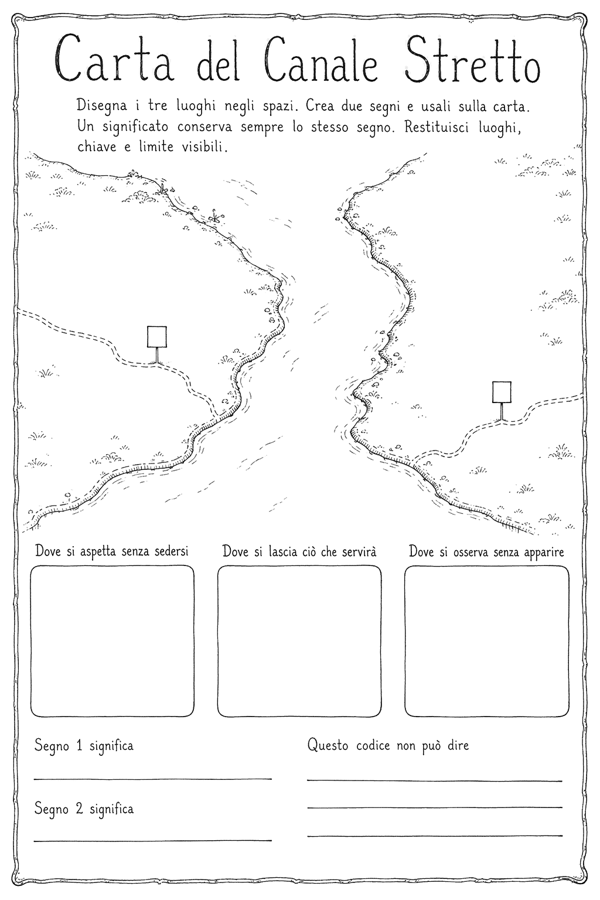

[3] collect: La carta può tornare



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.


--- RETURNED: synthetic handwriting (44.637 s) ---


<1093499 bytes>


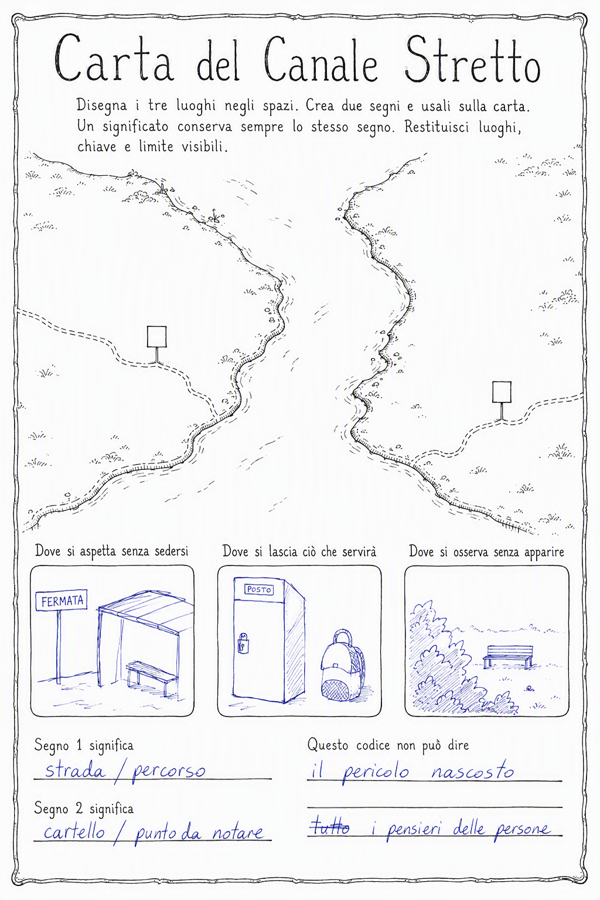


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (7.593 s) ---


{"written":true,"same_sheet":true,"describes":["blue drawing of a shelter, bench and a sign reading “FERMATA” in the left box","blue drawing of a locker marked “POSTO” and a backpack in the middle box","blue drawing of bushes and a bench in the right box","“strada / percorso” written on the Segno 1 line","“cartello / punto da notare” written on the Segno 2 line","“il pericolo nascosto” written on the first code line","crossed-out “tutto” followed by “i pensieri delle persone” on the second code line"]}



--- SENT: continuing aftn-9fe9dd1e after rientro ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third of the t

--- RETURNED: continuing aftn-9fe9dd1e after rientro (53.706 s) ---


{"moments":[{"act":"say","id":"shelter-reply","heading":"Il margine si apre","weights":{"short":{"minutes":1,"lines":["La FERMATA ha riparo e panchina.","Il suo margine sta arrivando."]},"standard":{"minutes":3,"lines":["La FERMATA ha riparo e panchina.","Il codice nomina strada e cartello.","Sta arrivando una tavola per il limite."]},"extended":{"minutes":5,"lines":["La FERMATA ha riparo e panchina.","Il POSTO custodisce uno zaino.","Il codice nomina strada e cartello.","Tieni accanto la prima carta."]}},"help":[{"after_minutes":1,"lines":["La FERMATA avrà un margine."]},{"after_minutes":3,"lines":["La nuova tavola userà i due segni."]},{"after_minutes":5,"lines":["Tieni la prima carta sul tavolo."]},{"after_minutes":8,"lines":["Prendi la Carta del Canale Stretto.","Posala accanto alla matita.","Attendi la nuova tavola.","Il canale resta aperto."]}],"way_out":{"in_hand":"Carta del Canale Stretto","heading":"La FERMATA rimane","lines":["Prendi la Carta del Canale Stretto.","Posala dava


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (2.078 s) ---


{"written":false,"same_sheet":true,"describes":[]}


{
  "status": "error",
  "reason": "RefusedByTheChecks: moments[1]: 'Metti in sequenza «strada / percorso» e «cartello / punto da notare».' still carries two options with a slash between them",
  "built_from": {
    "form": "invent-the-signs-write-the-key",
    "move": "named-by-what-happens-there"
  },
  "blank_reading": {
    "written": false,
    "same_sheet": true,
    "describes": [],
    "read_at": 1789482264.5256033,
    "degraded": false,
    "metadata": {
      "read_by": "page_reader",
      "request_id": "rq_31b561f9",
      "latency_s": 2.08
    }
  },
  "reading_in_continuation_prompt": false,
  "continuations": 0,
  "seconds": 288.771
}
Outcome: error RefusedByTheChecks: moments[1]: 'Metti in sequenza «strada / percorso» e «cartello / punto da notare».' still carries two options with a slash between them
Cell elapsed: 288.9 s
Artifacts: officina\runs\003-concrete-actions-20260915T142416846842Z


In [4]:
from research.workbench import live_activity


def seen(png: bytes) -> None:
    with Picture.open(io.BytesIO(png)) as picture:
        picture.thumbnail((620, 900))
        preview = io.BytesIO()
        picture.save(preview, format='PNG')
    display(Image(data=preview.getvalue()))


began = time.perf_counter()
try:
    RESULT = await live_activity(RUN, ARGS, show=seen)
    print('Outcome:', RESULT.status, RESULT.reason)
finally:
    print(f'Cell elapsed: {time.perf_counter() - began:.1f} s')
    print('Artifacts:', RUN.relative_to(ROOT))
if RUN.exists():
    (RUN / "prompt-snapshot.json").write_text(
        json.dumps(PROMPT_SNAPSHOT, ensure_ascii=False, indent=2),
        encoding="utf-8", newline="",
    )
    (RUN / "provenance.json").write_text(
        json.dumps(PROVENANCE, indent=2), encoding="utf-8", newline="",
    )


## Transcript and Verification

The transcript distinguishes display messages, generated paper, returned marks and continuations. The checks count what this run actually did, rather than planned moments.

In [5]:
EXPERIENCE = json.loads((RUN / 'experience.json').read_text(encoding='utf-8'))
VERIFICATION = json.loads((RUN / 'verification.json').read_text(encoding='utf-8'))
WALK = json.loads((RUN / 'walk.json').read_text(encoding='utf-8'))
CALLS = json.loads((RUN / 'calls.json').read_text(encoding='utf-8'))
display(Markdown('### ' + EXPERIENCE['title']))
print(EXPERIENCE['overview'])
print(EXPERIENCE['script'])
for number, event in enumerate(WALK['events'], 1):
    print(f"\n{number}. {event['act']} / {event['moment']}")
    print('\n'.join(event['lines']))
    if 'reading' in event:
        print('Synthetic return:', json.dumps(event['reading'], ensure_ascii=False))
    if 'continuation' in event:
        print('Continuation received:', len(event['continuation']['moments']), 'moments')
returns = [event for event in WALK['events'] if event.get('reading', {}).get('written')]
CHECKS = {
    'concluded': WALK['status'] == 'concluded',
    'multiple_returns': len(returns) >= 2,
    'multiple_sheets_within_ceiling': 2 <= len(WALK['pages']) <= ARGS['sheets'],
    'continuation_received': VERIFICATION['continuations'] >= 1,
    'reading_reaches_prompt': VERIFICATION['reading_in_continuation_prompt'],
    'blank_control': not VERIFICATION['blank_reading']['written']
        and not VERIFICATION['blank_reading']['degraded'],
    'no_fallback': not any(event.get('status') == 'fallback' for event in WALK['events']),
}
print(json.dumps({
    'checks': CHECKS, 'sheets': len(WALK['pages']), 'written_returns': len(returns),
    'measured_seconds': VERIFICATION['seconds'],
    'declared_minutes': WALK['declared_minutes'],
}, indent=2))
assert all(CHECKS.values()), CHECKS
print('PASS: complete synthetic multi-exchange game')

### L’atlante del Canale Stretto

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x000001BDCBE5F390>


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x000001BDCC2251D0>


Disegna tre luoghi inventati, li nomina per ciò che vi accade e crea un codice di due segni; negli scambi successivi amplia e modifica la mappa. La stampante produce fino a quattro tavole che insieme formano un atlante. Alla fine restano la mappa, la chiave e un cartiglio conclusivo. Non serve altro oltre a carta e matita. Richiede di restituire tre fogli e attendere tra gli scambi.
IL MONDO Il Canale Stretto è un luogo inventato diviso da un corso sinuoso. Tre zone non hanno ancora forma. Due sponde comunicano con un segnalatore capace di mostrare soltanto due segni inventati. La carta, il canale, le sponde e il segnalatore sono elementi di finzione. Le scelte, i segni e la mappa appartengono a chi li traccia. LA VIA D’ENTRATA La stampante fornisce la Carta del Canale Stretto. Si prende la carta e la matita dal tavolo. La prima azione è disegnare nei tre spazi i luoghi descritti dalle funzioni stampate. LA DOMANDA Come può una mappa descrivere un luogo e comunicare attraverso soltanto

AssertionError: {'concluded': False, 'multiple_returns': False, 'multiple_sheets_within_ceiling': False, 'continuation_received': False, 'reading_reaches_prompt': False, 'blank_control': True, 'no_fallback': True}

## Call Record

Durations are measured wall-clock seconds per logical call. SDK retries and Content Safety requests are not separate rows, so this is not a billing ledger. Physical legibility, handling, photography, delivery waits and comprehension still require a real afternoon.

In [ ]:
for number, call in enumerate(CALLS, 1):
    print(f"{number:2} {call['seconds']:8.1f} s {call['status']:6} {call['purpose']}")
print('Artifacts:', RUN.relative_to(ROOT))
print('Notebook iteration:', ITERATION)
print('Prompt fingerprint:', FINGERPRINT)

## Editorial Review: 15 September 2026

The run stopped after one printed page and one synthetic return. The continuation parsed, but the text check rejected "strada / percorso", wording copied from the return. The model-path measurement was 288.771 seconds; notebook execution took 300.7 seconds. The untouched-page control passed.

The drawing instructions are more concrete than in 002, but the first page asks for three places, two symbols, meanings and a limitation of the code. The large canal stays unused while drawings go into three small boxes. The synthetic return writes meanings without clearly drawing the two symbols; the reader reports no symbol shapes. A following instruction must not assume those symbols exist. No second sheet or ending was delivered.

Before 004, the prompts were changed to distribute work across exchanges, give the contribution useful drawing space, distinguish symbol meanings from reported shapes, and express slash-separated wording in prose. The application check remains unchanged and brittle. These are editorial hypotheses, not measurements of human comprehension. See [the comparison](comparison-002-004.md).